#### imports

In [182]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## *Extract the coins*

### original image

Text(0.5, 1.0, 'Original Image')

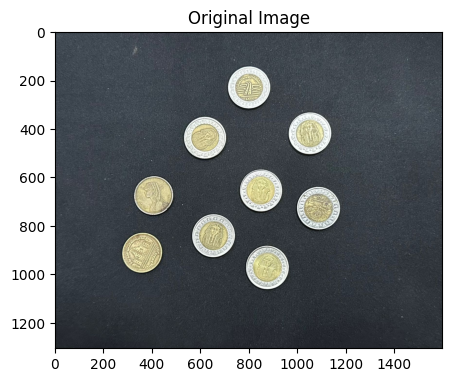

In [331]:
# Enable intellisense
%config IPCompleter.greedy=True

# Image path
imagePath = "/home/adham/Documents/Coin-Counting-System/EGP Coin Dataset/batch1/coin9.jpeg"
# Read image
# Store it in the variable image
###
image = cv2.imread(imagePath)
###
imageCopy = image.copy()
plt.imshow(image[:,:,::-1]);
plt.title("Original Image")

#### GrayScale

In [305]:

# # 1) Grayscale
# imageGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# # 2) Gaussian Blur
# imageBlur = cv2.GaussianBlur(imageGray, (5, 5), 0)

# # 3) Contrast Boost (Histogram Equalization)
# imageContrast = cv2.equalizeHist(imageBlur)

# # Display results
# plt.figure(figsize=(12,5))

# plt.subplot(141)
# plt.imshow(image[:,:,::-1])
# plt.title("Original Image")
# plt.axis("off")

# plt.subplot(142)
# plt.imshow(imageGray, cmap="gray")
# plt.title("Grayscale")
# plt.axis("off")

# plt.subplot(143)
# plt.imshow(imageBlur, cmap="gray")
# plt.title("Gaussian Blur")
# plt.axis("off")

# plt.subplot(144)
# plt.imshow(imageContrast, cmap="gray")
# plt.title("Contrast Boost")
# plt.axis("off")

# plt.show()

### Trials

#### trial 1

In [185]:
# _, imageThresh = cv2.threshold(imageContrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# plt.figure(figsize=(12,12))
# plt.subplot(141)
# plt.imshow(imageThresh, cmap="gray")
# plt.title("Binary (Otsu Threshold)")
# plt.axis("off")
# plt.show()

# gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# _,binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# plt.figure(figsize=(12,12))
# plt.subplot(142)
# plt.imshow(binary, cmap="gray")
# plt.title("Binary Image")
# plt.axis("off")
# plt.show()

#### trial 2

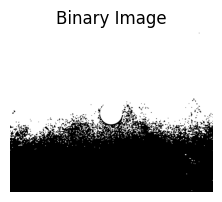

In [186]:
import cv2
import numpy as np

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 1) Blur to reduce small noise
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 2) Morphological opening (removes small white noise)
kernel = np.ones((4, 4), np.uint8)
clean = cv2.morphologyEx(blur, cv2.MORPH_OPEN, kernel, iterations=1)

# 3) (optional but strong) closing to smooth coin edges
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel, iterations=1)

# 4) Threshold (binarize)
_, binary = cv2.threshold(clean, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(12,12))
plt.subplot(142)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

#### extract coins 

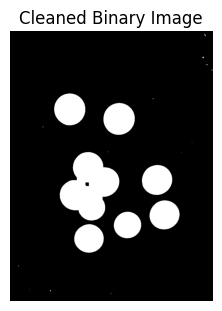

In [306]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((7,7), np.uint8)

# 1) fix internal noise
clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# 2) optional: fill object completely
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

mask = np.zeros_like(clean)
cv2.drawContours(mask, contours, -1, 255, -1)
clean = cv2.bitwise_and(clean, mask)

plt.figure(figsize=(12,12))
plt.subplot(142)
plt.imshow(clean, cmap="gray")
plt.title("Cleaned Binary Image")
plt.axis("off")
plt.show()


#### isolate a coin images

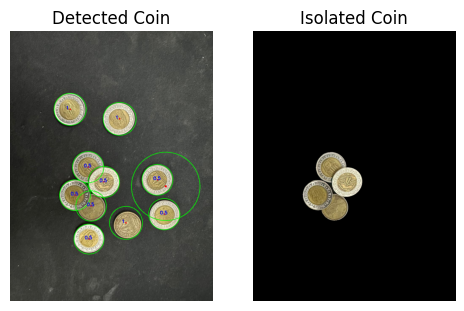

In [307]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((5,5), np.uint8)
clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest = max(contours, key=cv2.contourArea)

mask = np.zeros_like(clean)
cv2.drawContours(mask, [largest], -1, 255, -1)

coin_only = cv2.bitwise_and(image, image, mask=mask)

(_, _), radius = cv2.minEnclosingCircle(largest)
center = (int(_), int(_))
radius = int(radius)
cv2.circle(imageCopy, center, radius, (0, 255, 0), 2)
cv2.circle(imageCopy, center, 5, (0, 0, 255), -1)      
plt.figure(figsize=(12,12))
plt.subplot(141)
plt.imshow(imageCopy[:,:,::-1])
plt.title("Detected Coin")
plt.axis("off")
plt.subplot(142)
plt.imshow(coin_only[:,:,::-1])
plt.title("Isolated Coin")
plt.axis("off")
plt.show()

#### coin detection by radius

Detected coins: 7
Threshold radius: 113.0
Total money: 4.0


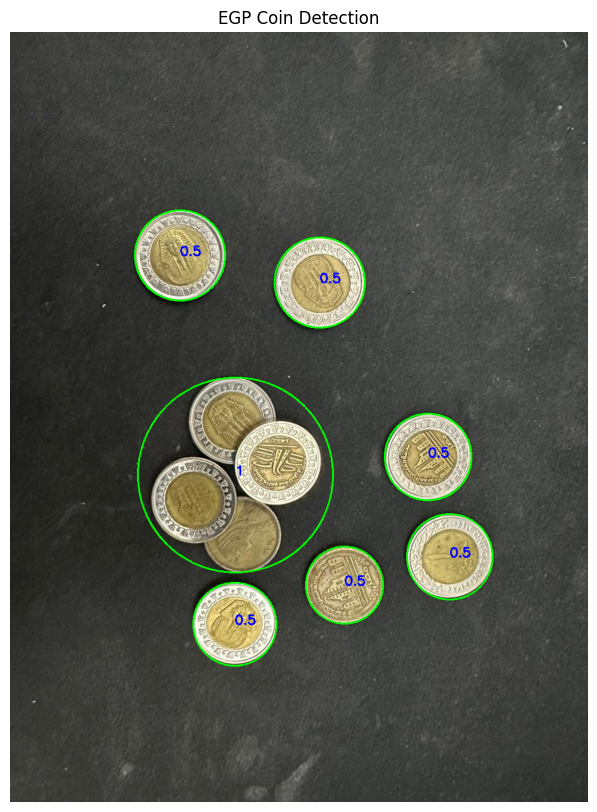

Total money: 4.0
75


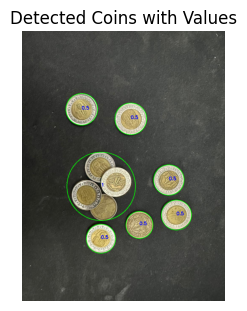

In [308]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imageCopy = image.copy()

# -------------------------
# 1. Preprocessing
# -------------------------
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((5, 5), np.uint8)
clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# -------------------------
# 2. Find contours
# -------------------------
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# -------------------------
# 3. Extract radii
# -------------------------
coins = []  # (radius, center)

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area < 100:   # remove noise
        continue

    (x, y), radius = cv2.minEnclosingCircle(cnt)
    radius = int(radius)

    coins.append((radius, (int(x), int(y))))

# -------------------------
# 4. Auto threshold (ONLY 2 COINS)
# -------------------------
radii = sorted([c[0] for c in coins])

if len(radii) >= 2:
    threshold = (radii[0] + radii[-1]) / 2
else:
    threshold = 0  # fallback

# -------------------------
# 5. Classification
# -------------------------
def classify_coin(radius, threshold):
    if radius < threshold:
        return 0.5      # small coin
    else:
        return 1    # large coin

total = 0

# -------------------------
# 6. Draw results
# -------------------------
for radius, center in coins:
    value = classify_coin(radius, threshold)
    total += value

    cv2.circle(imageCopy, center, radius, (0, 255, 0), 2)
    cv2.putText(imageCopy, str(value), center,
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

# -------------------------
# 7. Output
# -------------------------
print("Detected coins:", len(coins))
print("Threshold radius:", threshold)
print("Total money:", total)

plt.figure(figsize=(10, 10))
plt.imshow(imageCopy[:, :, ::-1])
plt.title("EGP Coin Detection")
plt.axis("off")
plt.show()

print("Total money:", total)
print(radius)
plt.figure(figsize=(12,12))
plt.subplot(141)
plt.imshow(imageCopy[:,:,::-1])
plt.title("Detected Coins with Values")
plt.axis("off")
plt.show()

## coin Overlapping

### overlapping coins trial 1

Coins detected: 7


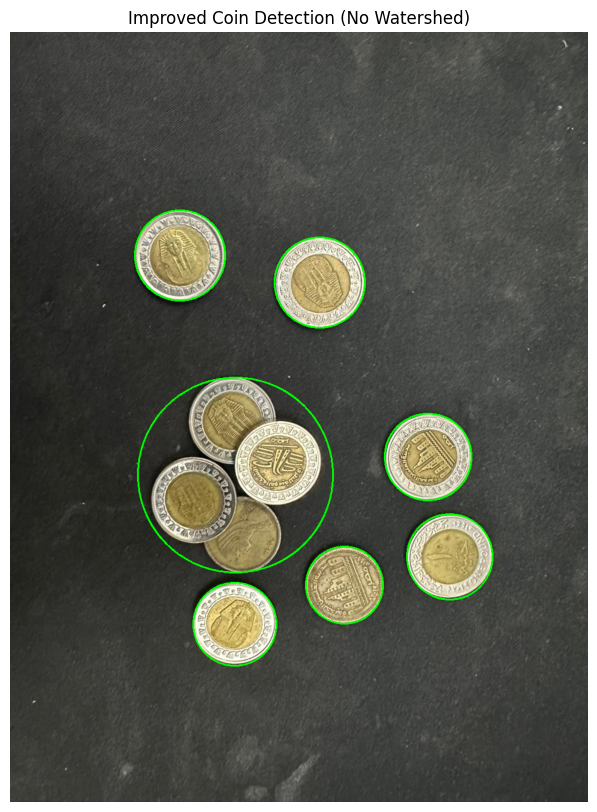

In [ ]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# img = image.copy()

# # -------------------------
# # 1. Preprocess
# # -------------------------
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# blur = cv2.GaussianBlur(gray, (5,5), 0)

# _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# kernel = np.ones((5,5), np.uint8)
# clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# # -------------------------
# # 2. Find contours (even merged ones)
# # -------------------------
# contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# result = img.copy()

# coins = []

# # -------------------------
# # 3. Split logic (important part)
# # -------------------------
# for cnt in contours:
#     area = cv2.contourArea(cnt)

#     if area < 200:
#         continue

#     # bounding circle first
#     (x, y), radius = cv2.minEnclosingCircle(cnt)
#     center = (int(x), int(y))
#     radius = int(radius)

#     # check if contour is too big → likely multiple coins stuck
#     if area > 2 * np.pi * (radius ** 2):
#         # SPLIT using K-means on contour points
#         Z = np.float32(cnt.reshape(-1,2))
#         K = 2  # since you said overlapping coins

#         criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
#         _, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

#         for c in centers:
#             c = tuple(map(int, c))
#             coins.append(c)
#             cv2.circle(result, c, 40, (0,255,0), 2)

#     else:
#         coins.append(center)
#         cv2.circle(result, center, radius, (0,255,0), 2)

# # -------------------------
# # 4. Show
# # -------------------------
# print("Coins detected:", len(coins))

# plt.figure(figsize=(10,10))
# plt.imshow(result[:,:,::-1])
# plt.title("Improved Coin Detection (No Watershed)")
# plt.axis("off")
# plt.show()

### *detecting the coins Overlapping*

Detected coins: 10
Total money: 6.5


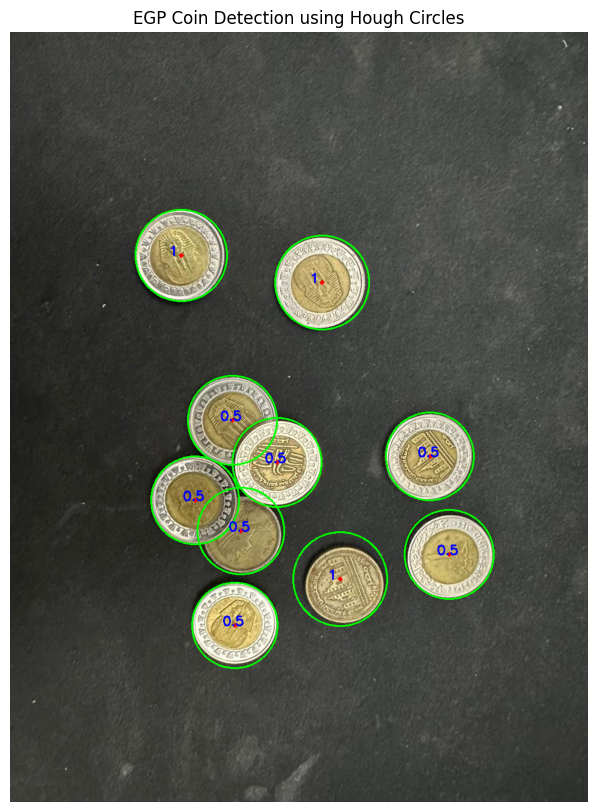

In [309]:
imageCopy = image.copy()

# -------------------------
# 1. Preprocessing
# -------------------------
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Important: stronger blur helps circle detection
blur = cv2.GaussianBlur(gray, (9, 9), 2)

# Optional contrast improvement (helps a lot for real images)
blur = cv2.equalizeHist(blur)

# -------------------------
# 2. Hough Circle Detection
# -------------------------
circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=40,        # minimum distance between coin centers
    param1=150,        # Canny high threshold
    param2=25,         # sensitivity (lower = more circles)
    minRadius=70,
    maxRadius=100
)

# -------------------------
# 3. Classification function (2 coins only)
# -------------------------
def classify_coin(radius, threshold):
    if radius < threshold:
        return 0.5
    else:
        return 1

coins = []
total = 0

# -------------------------
# 4. Process detected circles
# -------------------------
if circles is not None:
    circles = np.uint16(np.around(circles))

    # collect radii first (for automatic threshold)
    radii = [c[2] for c in circles[0, :]]
    radii = sorted(radii)

    threshold = (radii[0] + radii[-1]) / 2 if len(radii) > 1 else 0

    for c in circles[0, :]:
        x, y, r = c

        value = classify_coin(r, threshold)
        total += value

        coins.append((r, (x, y), value))

        # draw circle
        cv2.circle(imageCopy, (x, y), r, (0, 255, 0), 2)
        cv2.circle(imageCopy, (x, y), 2, (0, 0, 255), 3)

        # label
        cv2.putText(imageCopy, str(value), (x-20, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

# -------------------------
# 5. Output
# -------------------------
print("Detected coins:", len(coins))
print("Total money:", total)

plt.figure(figsize=(10, 10))
plt.imshow(imageCopy[:, :, ::-1])
plt.title("EGP Coin Detection using Hough Circles")
plt.axis("off")
plt.show()

### using hsv with Hough for coin extraction

Detected coins: 9
Total money: 8.0


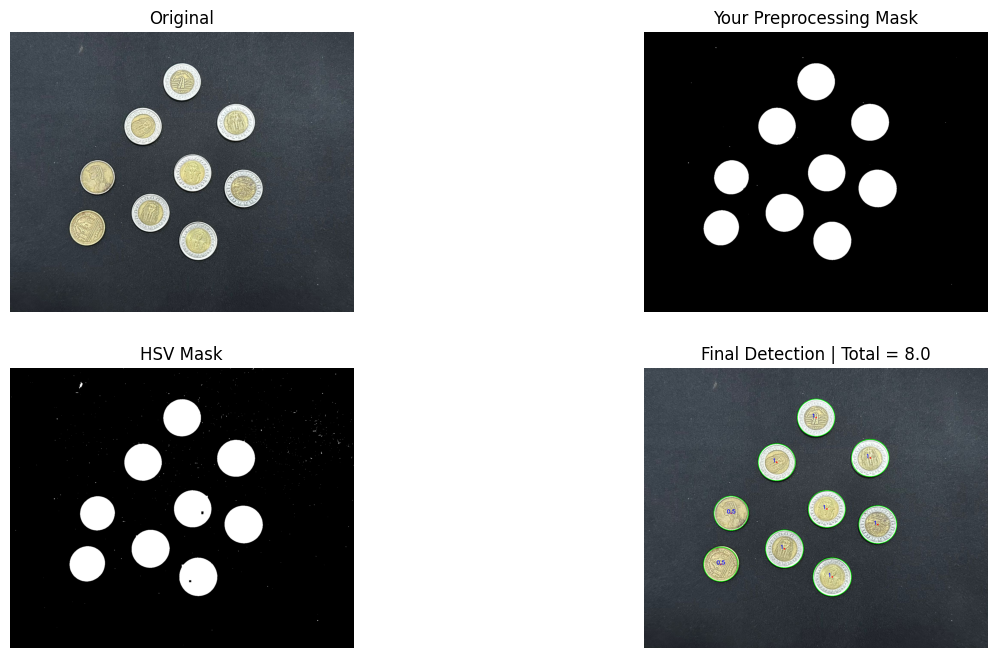

In [336]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imageCopy = image.copy()

# --------------------------------
# 1) YOUR preprocessing (Gray -> Blur -> Otsu -> Morph Close)
# --------------------------------
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((5,5), np.uint8)
clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# Make sure coins are WHITE for later combination
# If your coins are black in clean, invert it
# clean = cv2.bitwise_not(clean)

# --------------------------------
# 2) HSV MASK (filter coin colors)
# --------------------------------
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Example HSV range (YOU MUST TUNE THIS)
lower = np.array([0, 0, 120])
upper = np.array([179, 80, 255])

hsvMask = cv2.inRange(hsv, lower, upper)

# clean HSV mask
hsvMask = cv2.morphologyEx(hsvMask, cv2.MORPH_CLOSE, kernel, iterations=2)

# --------------------------------
# 3) Combine both masks (binary AND hsvMask)
# --------------------------------
combined = cv2.bitwise_and(clean, hsvMask)

# --------------------------------
# 4) Hough Circle Detection (on combined mask)
# --------------------------------
combinedBlur = cv2.GaussianBlur(combined, (9,9), 2)

circles = cv2.HoughCircles(
    combinedBlur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=60,
    param1=120,
    param2=30,
    minRadius=50,
    maxRadius=130
)

# --------------------------------
# 5) Classify coins (ONLY 2 COINS: 1 EGP and 0.5 EGP)
# --------------------------------
def classify_coin(radius, threshold):
    if radius < threshold:
        return 0.5
    else:
        return 1

coins = []
total = 0

if circles is not None:
    circles = np.uint16(np.around(circles))

    radii = sorted([c[2] for c in circles[0]])
    threshold = (radii[0] + radii[-1]) / 2 if len(radii) > 1 else radii[0]

    for x, y, r in circles[0]:
        value = classify_coin(r, threshold)
        total += value

        coins.append((x, y, r, value))

        cv2.circle(imageCopy, (x, y), r, (0, 255, 0), 2)
        cv2.circle(imageCopy, (x, y), 2, (0, 0, 255), 3)

        cv2.putText(imageCopy, str(value), (x-20, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

print("Detected coins:", len(coins))
print("Total money:", total)

# --------------------------------
# 6) Display Results
# --------------------------------
plt.figure(figsize=(15,8))

plt.subplot(221)
plt.imshow(image[:,:,::-1])
plt.title("Original")
plt.axis("off")

plt.subplot(222)
plt.imshow(clean, cmap="gray")
plt.title("Your Preprocessing Mask")
plt.axis("off")

plt.subplot(223)
plt.imshow(hsvMask, cmap="gray")
plt.title("HSV Mask")
plt.axis("off")

plt.subplot(224)
plt.imshow(imageCopy[:,:,::-1])
plt.title(f"Final Detection | Total = {total}")
plt.axis("off")

plt.show()

### fine tunning HSV -- in progress

/tmp/ipykernel_201125/1564945447.py:64: RuntimeWarning: overflow encountered in scalar subtract
  dist = np.sqrt((x - fx) ** 2 + (y - fy) ** 2)
/tmp/ipykernel_201125/1564945447.py:64: RuntimeWarning: overflow encountered in scalar add
  dist = np.sqrt((x - fx) ** 2 + (y - fy) ** 2)


Detected coins: 6
Total money: 3.0


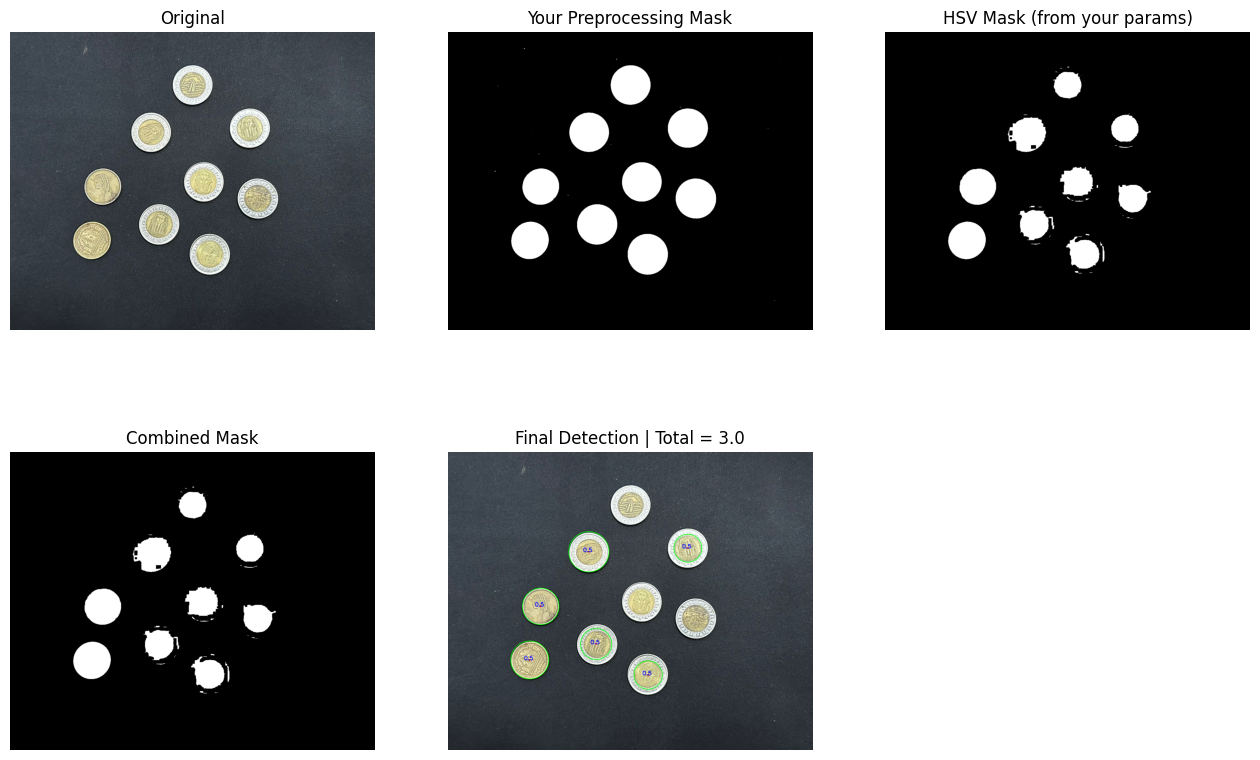

In [335]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS YOU PROVIDED
# -----------------------------
coin_params = {
    "EGP_1": {
        "radius": 49,
        "h": 27,
        "s": 1,
        "v": 213
    },
    "EGP_0.50": {
        "radius": 60,
        "h": 35,
        "s": 8,
        "v": 212
    }
}

# HSV tolerance (tune if needed)
H_TOL = 15
S_TOL = 80
V_TOL = 80


def hsv_range(h, s, v):
    lower = np.array([max(h - H_TOL, 0), max(s - S_TOL, 0), max(v - V_TOL, 0)])
    upper = np.array([min(h + H_TOL, 179), min(s + S_TOL, 255), min(v + V_TOL, 255)])
    return lower, upper


def classify_by_radius(r):
    r1 = coin_params["EGP_1"]["radius"]
    r05 = coin_params["EGP_0.50"]["radius"]

    if abs(r - r05) < abs(r - r1):
        return 0.5
    else:
        return 1


def filter_inner_circles(circles, center_thresh=30):
    """
    Removes inner circle detections inside the same coin.
    Keeps only the largest radius circle if centers are close.
    """
    if circles is None:
        return []

    circles = np.uint16(np.around(circles[0]))

    # sort by radius descending (largest first)
    circles = sorted(circles, key=lambda c: c[2], reverse=True)

    filtered = []

    for x, y, r in circles:
        keep = True

        for fx, fy, fr in filtered:
            dist = np.sqrt((x - fx) ** 2 + (y - fy) ** 2)

            # if circle center is very close -> same coin -> ignore smaller circle
            if dist < center_thresh:
                keep = False
                break

        if keep:
            filtered.append((x, y, r))

    return filtered


# =========================================================
# MAIN PIPELINE
# =========================================================

# image must already be loaded before running this script
# example:
# image = cv2.imread("your_image.jpg")

imageCopy = image.copy()

# --------------------------------
# 1) YOUR preprocessing (Gray -> Blur -> Otsu -> Morph Close)
# --------------------------------
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((5, 5), np.uint8)
clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# If your coins appear black and background white, invert it:
# clean = cv2.bitwise_not(clean)

# --------------------------------
# 2) HSV MASK using your parameters
# --------------------------------
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower1, upper1 = hsv_range(
    coin_params["EGP_1"]["h"],
    coin_params["EGP_1"]["s"],
    coin_params["EGP_1"]["v"]
)
mask_egp1 = cv2.inRange(hsv, lower1, upper1)

lower05, upper05 = hsv_range(
    coin_params["EGP_0.50"]["h"],
    coin_params["EGP_0.50"]["s"],
    coin_params["EGP_0.50"]["v"]
)
mask_egp05 = cv2.inRange(hsv, lower05, upper05)

# Combine HSV masks
hsvMask = cv2.bitwise_or(mask_egp1, mask_egp05)

# Clean HSV mask
hsvMask = cv2.morphologyEx(hsvMask, cv2.MORPH_CLOSE, kernel, iterations=2)

# --------------------------------
# 3) Combine masks (binary AND hsvMask)
# --------------------------------
combined = cv2.bitwise_and(clean, hsvMask)

# --------------------------------
# 4) Hough Circle Detection
# --------------------------------
combinedBlur = cv2.GaussianBlur(combined, (9, 9), 2)

circles = cv2.HoughCircles(
    combinedBlur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=80,
    param1=120,
    param2=40,
    minRadius=50,   # important: avoids inner ring detection
    maxRadius=90
)

# Filter inner circles
filtered_circles = filter_inner_circles(circles, center_thresh=30)

# --------------------------------
# 5) Classify + Draw results
# --------------------------------
coins = []
total = 0

for x, y, r in filtered_circles:
    value = classify_by_radius(r)
    total += value

    coins.append((x, y, r, value))

    cv2.circle(imageCopy, (x, y), r, (0, 255, 0), 2)
    cv2.circle(imageCopy, (x, y), 2, (0, 0, 255), 3)

    cv2.putText(imageCopy, str(value), (x - 25, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

print("Detected coins:", len(coins))
print("Total money:", total)

# --------------------------------
# 6) Display Results
# --------------------------------
plt.figure(figsize=(16, 10))

plt.subplot(231)
plt.imshow(image[:, :, ::-1])
plt.title("Original")
plt.axis("off")

plt.subplot(232)
plt.imshow(clean, cmap="gray")
plt.title("Your Preprocessing Mask")
plt.axis("off")

plt.subplot(233)
plt.imshow(hsvMask, cmap="gray")
plt.title("HSV Mask (from your params)")
plt.axis("off")

plt.subplot(234)
plt.imshow(combined, cmap="gray")
plt.title("Combined Mask")
plt.axis("off")

plt.subplot(235)
plt.imshow(imageCopy[:, :, ::-1])
plt.title(f"Final Detection | Total = {total}")
plt.axis("off")

plt.show()

continue.....

#### *Todo list*

```
[]tunning the parametes for the HSV and hough and morphological operations
[]solve the problem with the single coin data
[]check for any improvements
[]add real time detection 

```